In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Example shapes: (time, x, y, z)
nt, nx, ny, nz = 1000, 50, 50, 10
dt = 1.0  # time step in seconds

# -------------------------
# Example data (replace with your data)
# -------------------------
u_tot = np.random.randn(nt, nx, ny, nz, 3)  # total velocity vector (u,v,w)
u_iw = np.random.randn(nt, nx, ny, nz, 3)   # internal-wave velocity vector

# -------------------------
# 1) Simple velocity subtraction (linear approx)
# -------------------------
u_res_linear = u_tot - u_iw


# -------------------------
# u_res_linear: linear approx residual velocity
# u_res_accel: nonlinear-aware residual velocity
# -------------------------
print("Linear residual velocity shape:", u_res_linear.shape)


Linear residual velocity shape: (1000, 50, 50, 10, 3)


In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import os

import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend

from matplotlib.ticker import LogLocator, FuncFormatter

import sys
sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config
from utils_signal_processing import *

# Load data and select ZZ

In [3]:
model = 'dummy_geneva'
mitgcm_config, ds = open_mitgcm_ds_from_config('..//config.json', model)

In [5]:
grid_resolution = 200
ds['YC'] = np.arange(1, len(ds['YC'])+1) * grid_resolution - grid_resolution/2
ds['XC'] = np.arange(1, len(ds['XC'])+1) * grid_resolution - grid_resolution/2
ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

In [6]:
zz = 0

In [7]:
u = ds.UVEL.sel(Z=zz,method='nearest').isel(time=range(8,len(ds['time'])))
v = ds.VVEL.sel(Z=zz,method='nearest').isel(time=range(8,len(ds['time'])))
w = ds.WVEL.sel(Zl=zz,method='nearest').isel(time=range(8,len(ds['time'])))

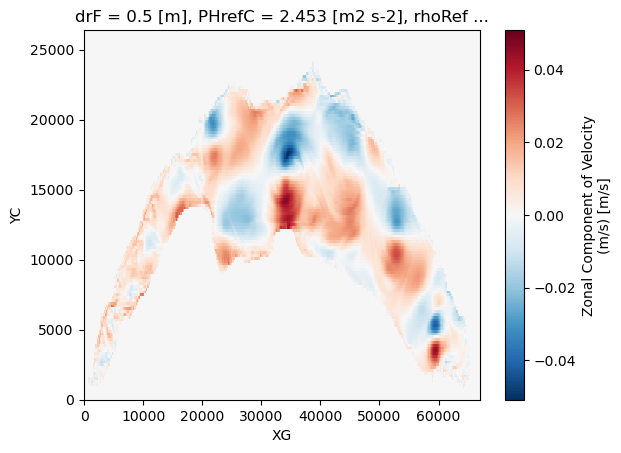

In [8]:
ds.UVEL.isel(Z=0, time=-1).plot()

In [ ]:
u_tot = u

In [11]:
def advect(u, dx=1.0):
    """Compute advection term u.grad(u) using central differences"""
    dudx = (np.roll(u, -1, axis=1) - np.roll(u, 1, axis=1)) / (2*dx)
    dudy = (np.roll(u, -1, axis=2) - np.roll(u, 1, axis=2)) / (2*dx)
    dudz = (np.roll(u, -1, axis=3) - np.roll(u, 1, axis=3)) / (2*dx)
    adv = u[...,0:1]*dudx + u[...,1:2]*dudy + u[...,2:3]*dudz
    return adv

# Compute nonlinear acceleration
a_tot = np.gradient(u_tot, dt, axis=0) + advect(u_tot)
a_iw  = np.gradient(u_iw, dt, axis=0) + advect(u_iw)
a_res = a_tot - a_iw

# Integrate residual using nonlinear advection
u_res_accel = np.zeros_like(u_tot)
u_res_accel[0] = u_tot[0] - u_iw[0]

for t in range(1, nt):
    # Update with residual acceleration
    u_res_accel[t] = u_res_accel[t-1] + a_res[t-1] * dt

print("Acceleration-based residual velocity shape:", u_res_accel.shape)

Acceleration-based residual velocity shape: (1000, 50, 50, 10, 3)


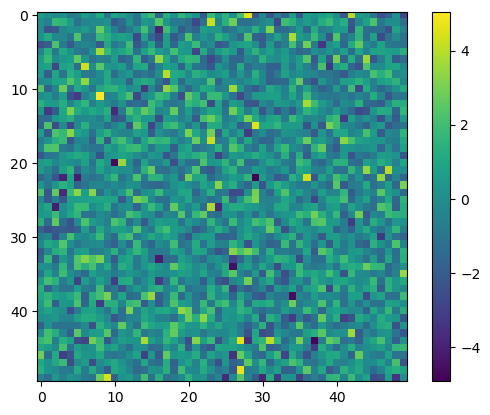

In [15]:
plt.imshow(u_res_linear[2,:,:,0,0])
plt.colorbar()

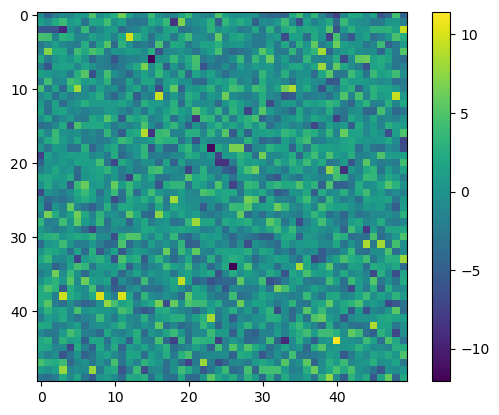

In [16]:
plt.imshow(u_res_accel[2,:,:,0,0])
plt.colorbar()